# Import Libraries

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [138]:
df=pd.read_csv('train.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [139]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Descriptive Statistics

In [140]:
df.info()
df.shape
df.describe()
df.count()
df.mean()
df.var()
df.std()
df.min()
df.max()
df.quantile()
df.nunique()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


C:\Users\harsh\AppData\Local\Temp\ipykernel_10864\2013870531.py:5: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df.mean()
C:\Users\harsh\AppData\Local\Temp\ipykernel_10864\2013870531.py:6: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df.var()
C:\Users\harsh\AppData\Local\Temp\ipykernel_10864\2013870531.py:7: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df.std()
C:\Users\harsh\AppData\Local\Temp\ipykernel_10864\2013870531.py:8: FutureWarning: Dropping of nuisance columns in DataFrame

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Data Cleaning

In [141]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [142]:
df['deck'] = df['Cabin'].str[0]
df['deck'] = df['deck'].fillna('U')

In [143]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
deck           0
dtype: int64

# Feature Engineering

In [144]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['Deck'] = df['Cabin'].fillna('Unknown').str[0]
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,19,35,60,100], labels=['Child','Teen','Young Adult','Adult','Senior'])
df['FareGroup'] = pd.qcut(df['Fare'], 4,labels=['Low','Medium','High','Very High'])

In [145]:
df.head()
df[['FamilySize','IsAlone','Deck','Title','AgeGroup','FareGroup']].head()

,FamilySize,IsAlone,Deck,Title,AgeGroup,FareGroup
0,2,0,U,Mr,Young Adult,Low
1,2,0,C,Mrs,Adult,Very High
2,1,1,U,Miss,Young Adult,Medium
3,2,0,C,Mrs,Young Adult,Very High
4,1,1,U,Mr,Young Adult,Medium


# univariate Analysis(Survival Comparisons)

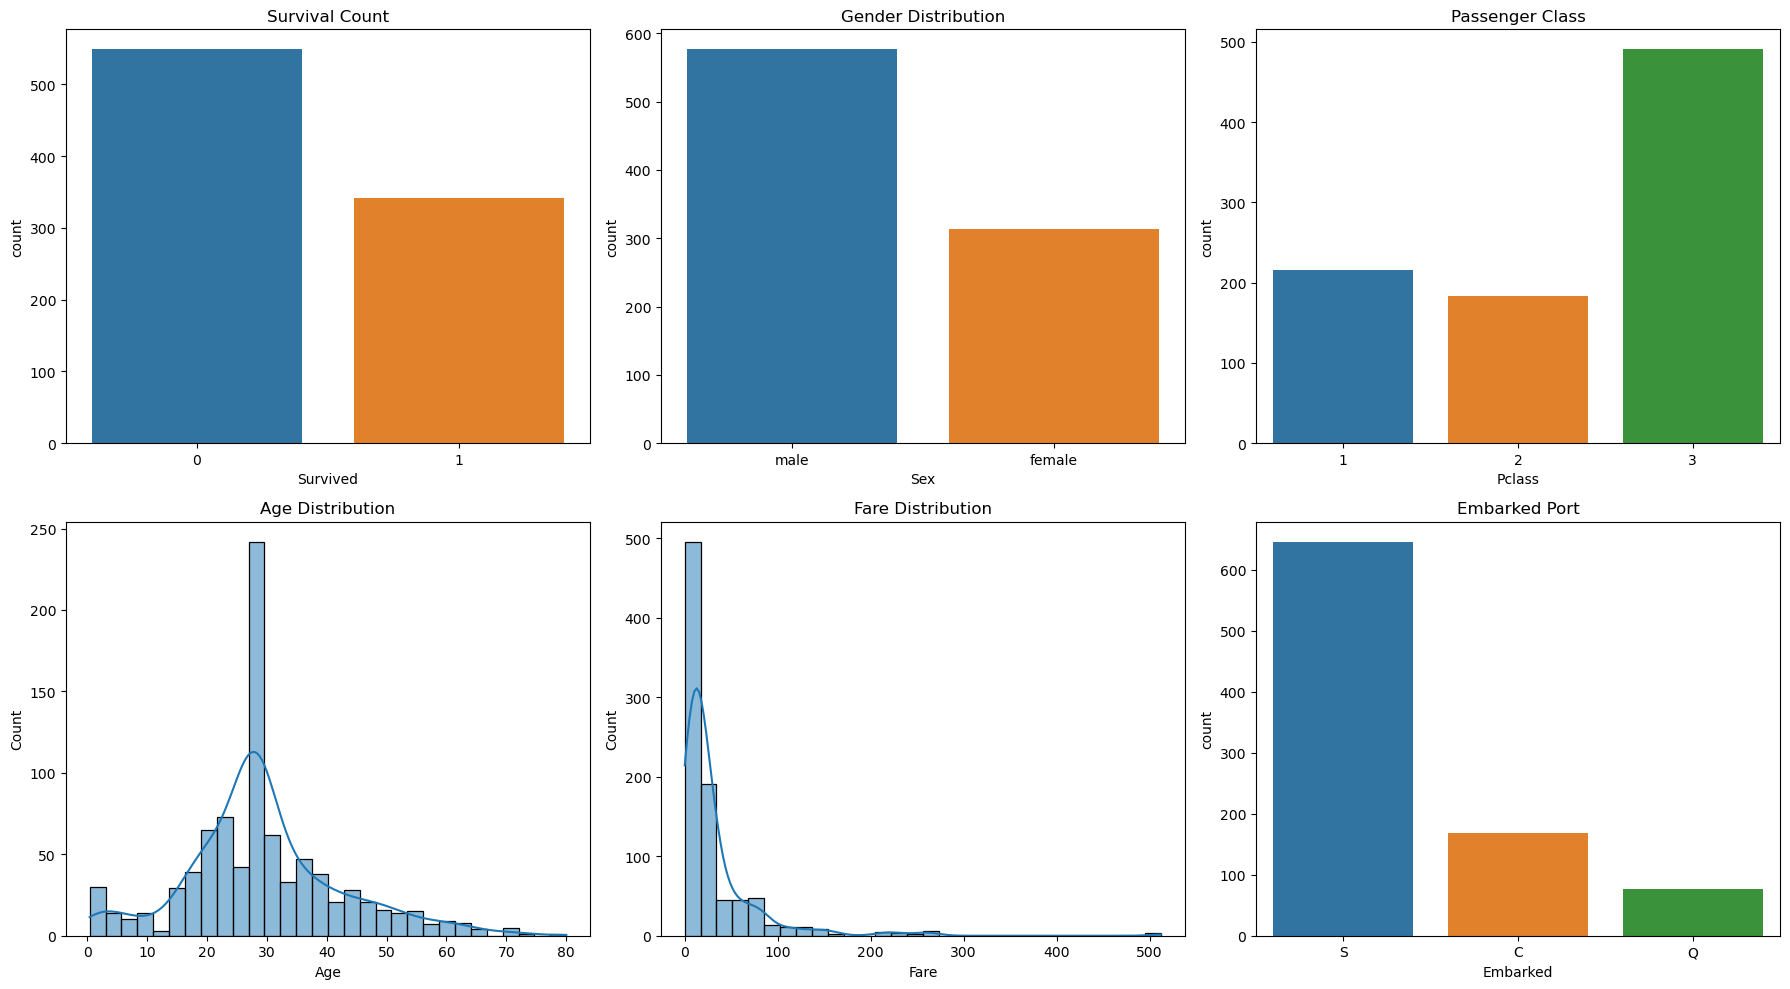

In [146]:


fig, axes = plt.subplots(2, 3, figsize=(18,10))

# 1️⃣ Survival Count
sns.countplot(x='Survived', data=df, ax=axes[0,0])
axes[0,0].set_title("Survival Count")

# 2️⃣ Gender Distribution
sns.countplot(x='Sex', data=df, ax=axes[0,1])
axes[0,1].set_title("Gender Distribution")

# 3️⃣ Passenger Class
sns.countplot(x='Pclass', data=df, ax=axes[0,2])
axes[0,2].set_title("Passenger Class")

# 4️⃣ Age Distribution
sns.histplot(df['Age'], kde=True, bins=30, ax=axes[1,0])
axes[1,0].set_title("Age Distribution")

# 5️⃣ Fare Distribution
sns.histplot(df['Fare'], kde=True, bins=30, ax=axes[1,1])
axes[1,1].set_title("Fare Distribution")

# 6️⃣ Embarked Port
sns.countplot(x='Embarked', data=df, ax=axes[1,2])
axes[1,2].set_title("Embarked Port")

# Adjust layout
plt.tight_layout()
plt.show()

# Bivariate Analysis(Survival Comparisons)

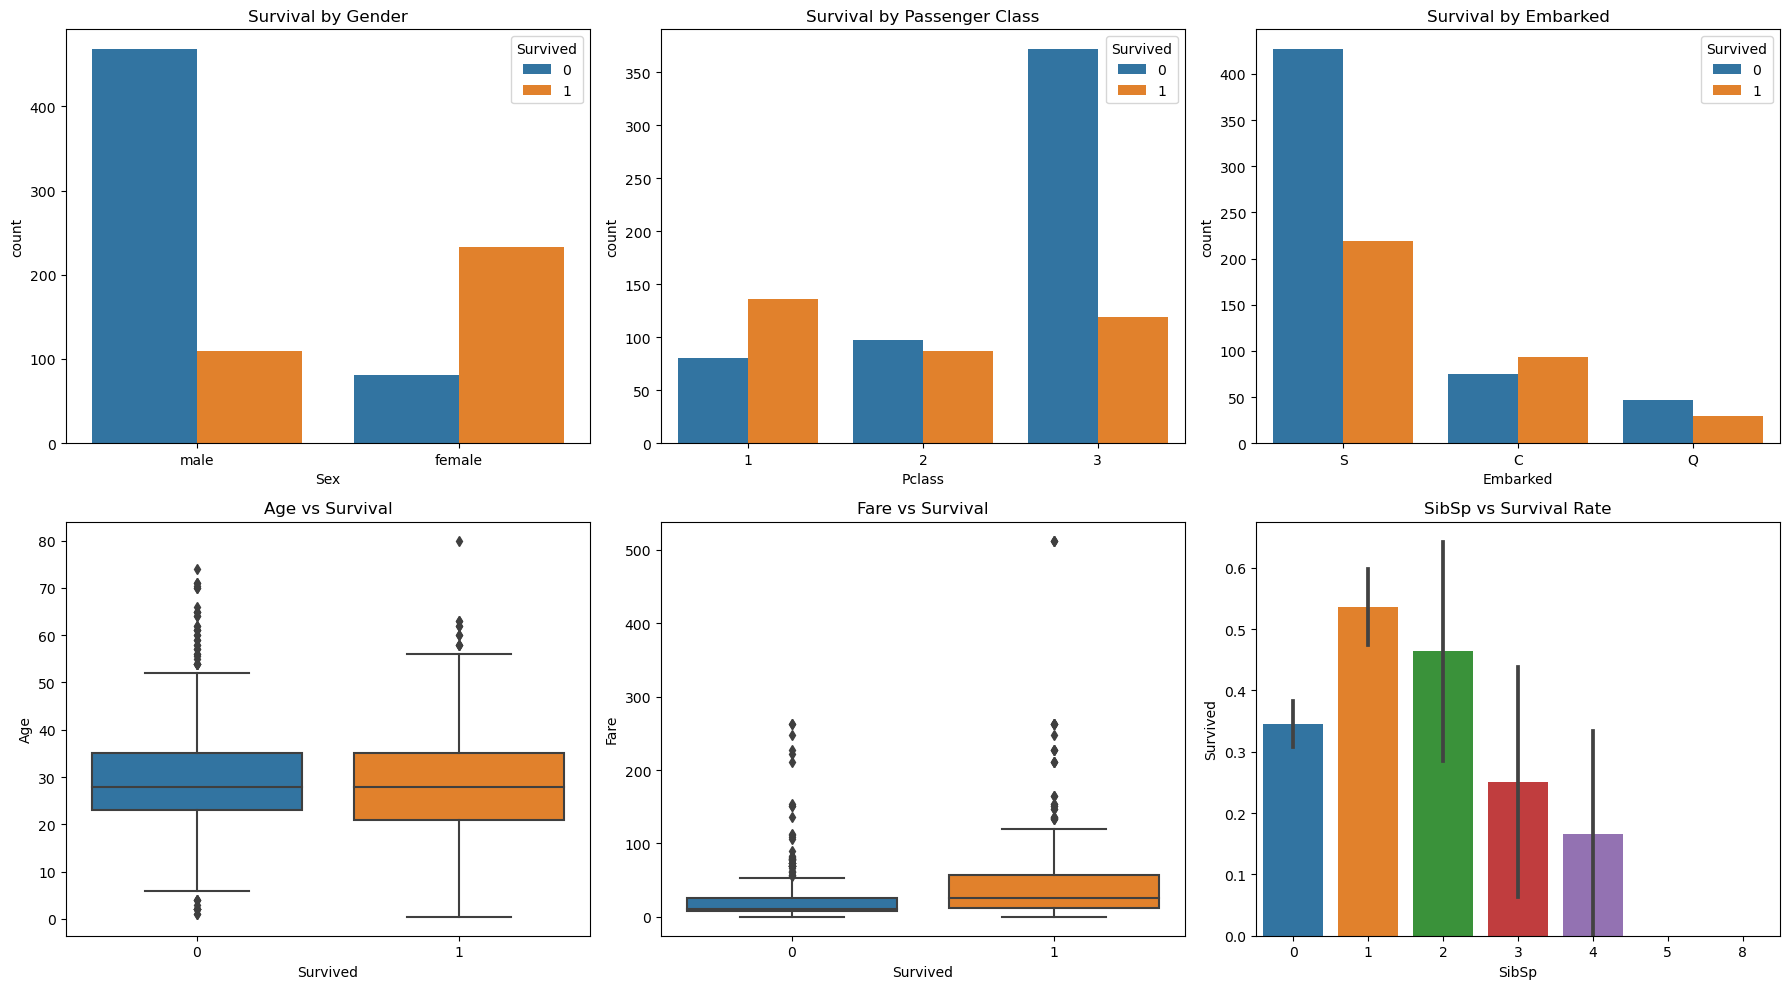

In [147]:


fig, axes = plt.subplots(2, 3, figsize=(18,10))

# 1️⃣ Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0,0])
axes[0,0].set_title("Survival by Gender")

# 2️⃣ Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[0,1])
axes[0,1].set_title("Survival by Passenger Class")

# 3️⃣ Survival by Embarked Port
sns.countplot(x='Embarked', hue='Survived', data=df, ax=axes[0,2])
axes[0,2].set_title("Survival by Embarked")

# 4️⃣ Survival by Age
sns.boxplot(x='Survived', y='Age', data=df, ax=axes[1,0])
axes[1,0].set_title("Age vs Survival")

# 5️⃣ Survival by Fare
sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[1,1])
axes[1,1].set_title("Fare vs Survival")

# 6️⃣ Survival Rate by SibSp
sns.barplot(x='SibSp', y='Survived', data=df, ax=axes[1,2])
axes[1,2].set_title("SibSp vs Survival Rate")

# Adjust layout
plt.tight_layout()
plt.show()

# Correlation Analysis and Outlier Detection

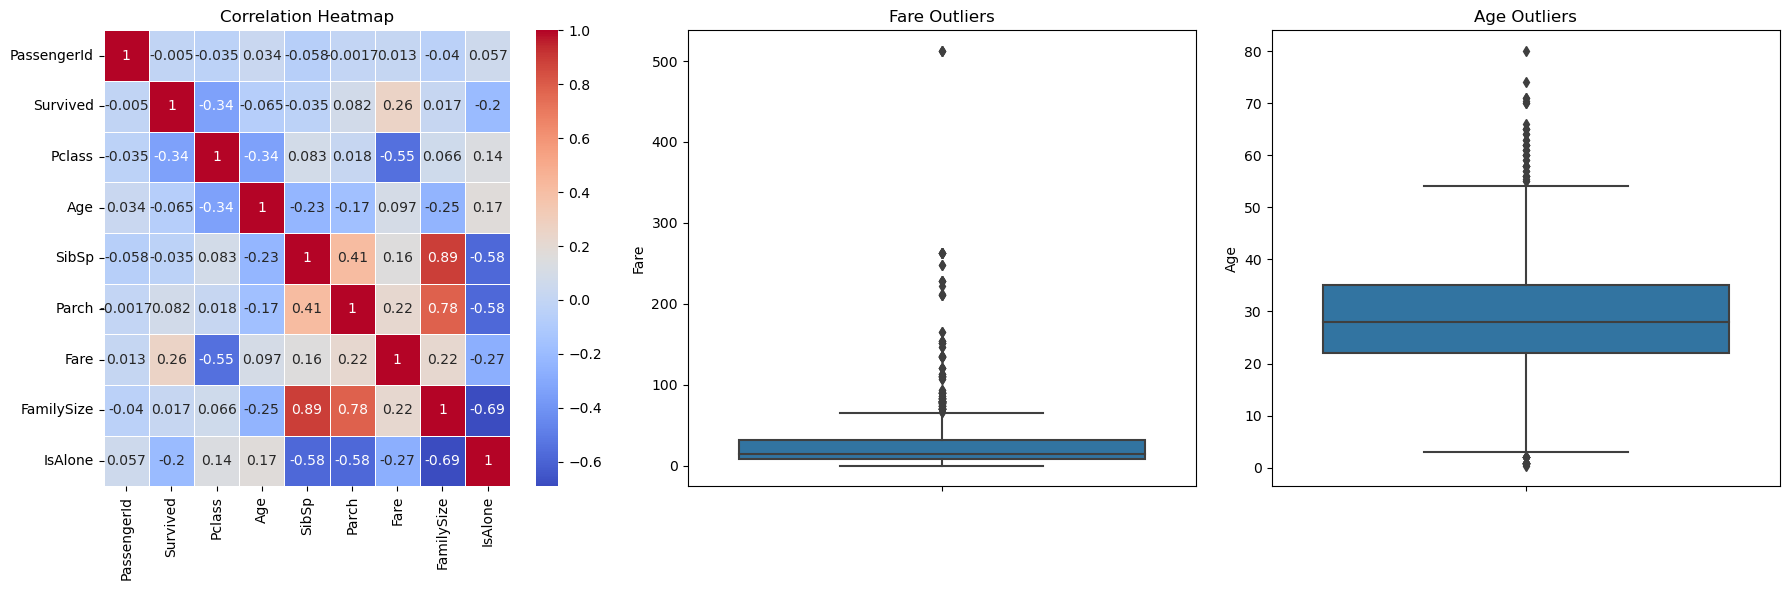

In [148]:


fig, axes = plt.subplots(1, 3, figsize=(18,6))

# 1️⃣ Correlation Heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm',
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Correlation Heatmap")

# 2️⃣ Fare Outliers
sns.boxplot(y=df['Fare'], ax=axes[1])
axes[1].set_title("Fare Outliers")

# 3️⃣ Age Outliers
sns.boxplot(y=df['Age'], ax=axes[2])
axes[2].set_title("Age Outliers")

# Adjust layout
plt.tight_layout()
plt.show()

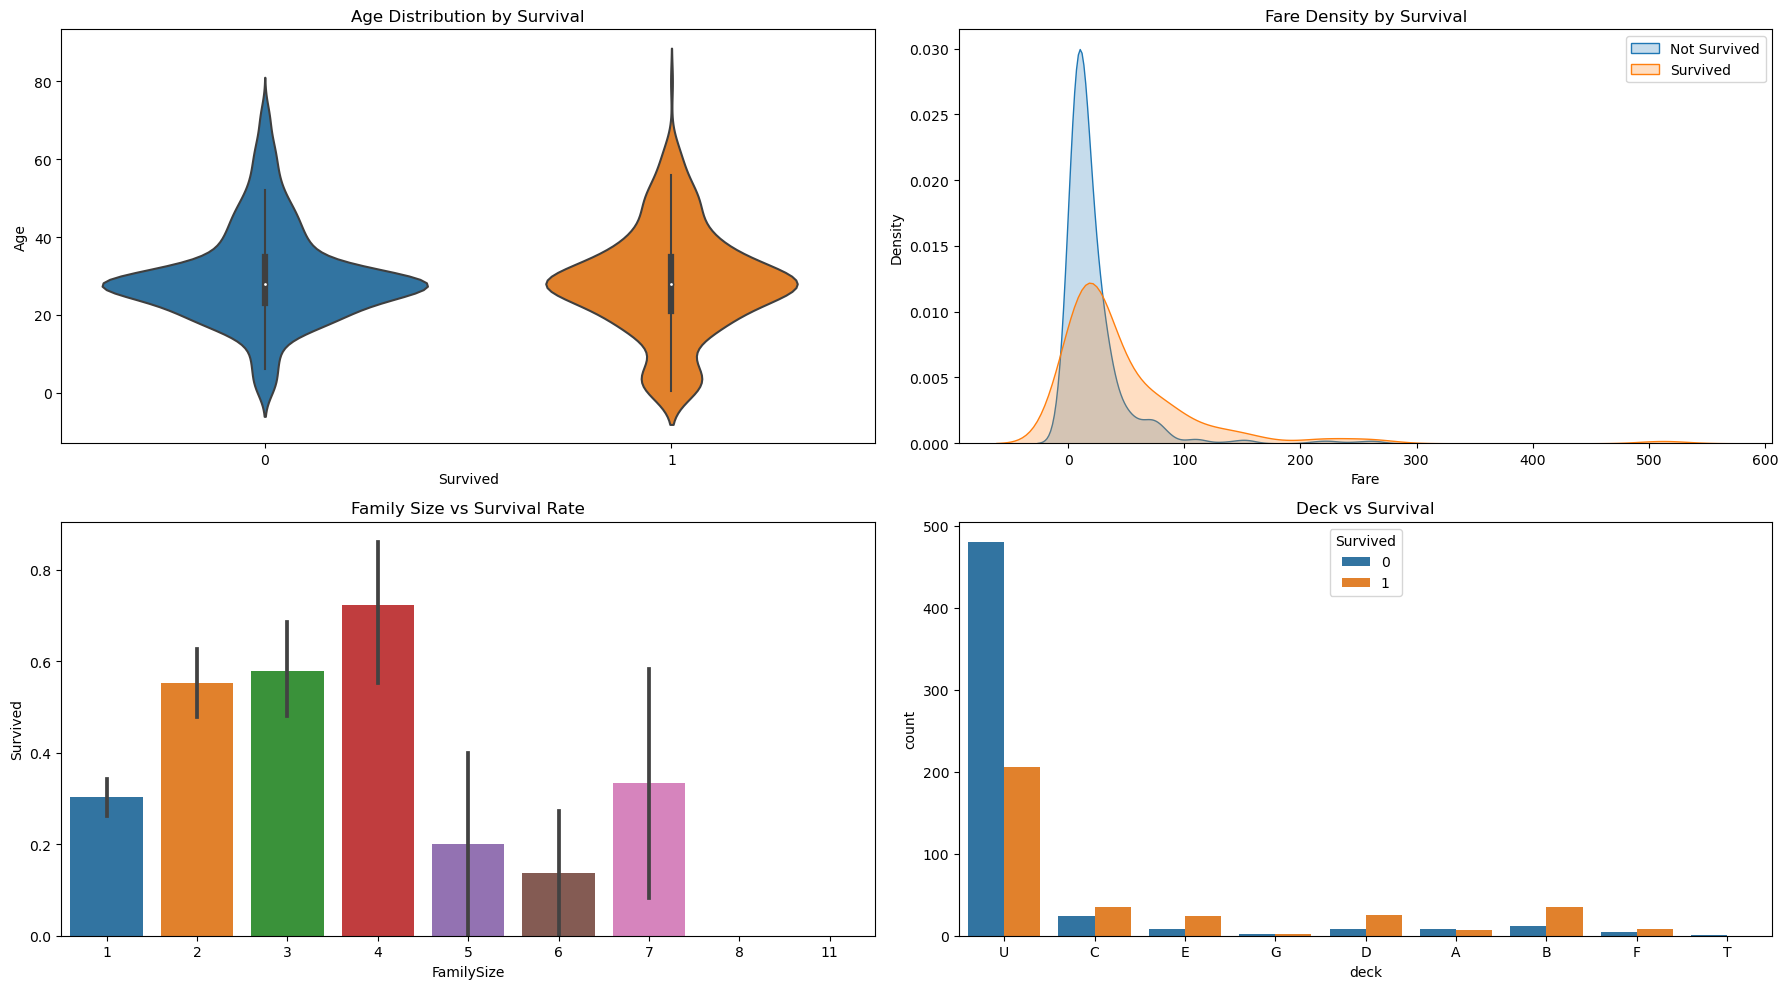

In [149]:
# 📌 ADVANCED ANALYSIS CHARTS (Compact Recruiter-Friendly Format)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(18,10))

# 1️⃣ Violin Plot - Age vs Survival
sns.violinplot(x='Survived', y='Age', data=df, ax=axes[0,0])
axes[0,0].set_title("Age Distribution by Survival")

# 2️⃣ KDE Plot - Fare by Survival
sns.kdeplot(data=df[df['Survived']==0]['Fare'],
            fill=True, label='Not Survived', ax=axes[0,1])

sns.kdeplot(data=df[df['Survived']==1]['Fare'],
            fill=True, label='Survived', ax=axes[0,1])

axes[0,1].set_title("Fare Density by Survival")
axes[0,1].legend()

# 3️⃣ Family Size vs Survival
sns.barplot(x='FamilySize', y='Survived', data=df, ax=axes[1,0])
axes[1,0].set_title("Family Size vs Survival Rate")

# 4️⃣ Deck vs Survival
sns.countplot(x='deck', hue='Survived', data=df, ax=axes[1,1])
axes[1,1].set_title("Deck vs Survival")

plt.tight_layout()
plt.show()

# 📌 KEY INSIGHTS


# - Female passengers had a higher survival rate than male passengers.
#  - First-class passengers were more likely to survive.
# - Higher fare passengers had better survival chances.
# - Most passengers were between the ages  of 20 to 40.
# - Children had relatively better survival chances.
# - The Cabin column contained many missing values.
# - The Fare column contained outliers.
# - Passenger class and gender strongly affected survival.
# ** Overall Insight: ** Survival was strongly influenced by gender, passenger class,  and  fare amount.

# 📌 Conclusion

# The analysis  shows that class,  gender,  age,  and fare played a major role in  passenger  survival. EDA  helped uncover important  insights from the Titanic  dataset.